Affichage des 5 permières lignes

In [123]:
import pandas as pd
import chardet
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


path="/Users/amar/Desktop/Alyra_School/Alyra 2025/4- Projet/investments_VC.csv"     #chemin d'accès
f = open(path, 'rb')        # ouverture du fihcier en mode binaire Read Binary
line = f.readline()         # detection de l'encodage du fichier
print(chardet.detect(line)) # detection automatique de l'encodage -> chardet renvoie un dictionnaire avec :'encoding' → le nom de l’encodage détecté,'confidence' → le niveau de confiance (entre 0 et 1),'language' → la langue si détectée)
data=pd.read_csv(path,encoding='unicode_escape')
data.info()

{'encoding': 'ascii', 'confidence': 1.0, 'language': ''}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   permalink             49438 non-null  object 
 1   name                  49437 non-null  object 
 2   homepage_url          45989 non-null  object 
 3   category_list         45477 non-null  object 
 4    market               45470 non-null  object 
 5    funding_total_usd    49438 non-null  object 
 6   status                48124 non-null  object 
 7   country_code          44165 non-null  object 
 8   state_code            30161 non-null  object 
 9   region                44165 non-null  object 
 10  city                  43322 non-null  object 
 11  funding_rounds        49438 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quart

Data Cleaning

In [124]:
data.rename(columns={' market ':'market',' funding_total_usd ':'funding_total_usd'},inplace=True) # suppresion des espaces
data.head(10)


,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,/organization/club-domains,.Club Domains,http://nic.club/,|Software|,Software,"70,00,000",NaN,USA,FL,Ft. Lauderdale,...,0.0,0.0,0.0,7000000.0,0.0,0.0,0.0,0.0,0.0,0.0
6,/organization/fox-networks,.Fox Networks,http://www.dotfox.com,|Advertising|,Advertising,"49,12,393",closed,ARG,NaN,Buenos Aires,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,/organization/0-6-com,0-6.com,http://www.0-6.com,|Curated Web|,Curated Web,"20,00,000",operating,NaN,NaN,NaN,...,0.0,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,|Software|,Software,-,operating,USA,IL,"Springfield, Illinois",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,/organization/01games-technology,01Games Technology,http://www.01games.hk/,|Games|,Games,"41,250",operating,HKG,NaN,Hong Kong,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Checking duplicated Entries

In [125]:
print('Duplicated entries:',data.duplicated().sum())
data[data.duplicated()].isna().mean()           #data.duplicated() : renvoie une série booléenne qui indique True pour chaque ligne en double (c’est-à-dire qui a déjà été vue plus tôt).
                                                #.sum() : compte le nombre total de lignes dupliquées (True = 1, False = 0).
                                                # print(...) : affiche combien de lignes sont des doublons.

Duplicated entries: 4855


permalink               1.0
name                    1.0
homepage_url            1.0
category_list           1.0
market                  1.0
funding_total_usd       1.0
status                  1.0
country_code            1.0
state_code              1.0
region                  1.0
city                    1.0
funding_rounds          1.0
founded_at              1.0
founded_month           1.0
founded_quarter         1.0
founded_year            1.0
first_funding_at        1.0
last_funding_at         1.0
seed                    1.0
venture                 1.0
equity_crowdfunding     1.0
undisclosed             1.0
convertible_note        1.0
debt_financing          1.0
angel                   1.0
grant                   1.0
private_equity          1.0
post_ipo_equity         1.0
post_ipo_debt           1.0
secondary_market        1.0
product_crowdfunding    1.0
round_A                 1.0
round_B                 1.0
round_C                 1.0
round_D                 1.0
round_E             

Checking Nans

In [126]:
data_na=data.isna().mean().to_frame()                           #data.isna()→ Crée un DataFrame booléen : True si la cellule est vide (NaN),False sinon.
                                                                #.mean()→ Calcule la moyenne par colonne, ce qui revient à calculer le taux de valeurs manquantes pour chaque colonne.
                                                                # .to_frame()→ Convertit le résultat (qui est une Série) en un DataFrame (tableau à une colonne), pour faciliter l'affichage ou la visualisation.
                                                                # data_na = ...→ Stocke ce tableau dans une nouvelle variable appelée data_na
data_na[data_na[0]>0].style.background_gradient(cmap='Blues')   
                                                                
                                                                

,0
permalink,0.089439
name,0.089457
homepage_url,0.152963
category_list,0.162394
market,0.162523
funding_total_usd,0.089439
status,0.113641
country_code,0.186558
state_code,0.444487
region,0.186558


Quick Analysis

In [127]:
data.founded_year.describe()            #Élément	Signification
                                        # count	    Le nombre de valeurs non nulles dans la colonne founded_year
                                        # mean	    La moyenne des années de fondation
                                        # std	    L'écart type, qui mesure la dispersion autour de la moyenne
                                        # min	    L'année la plus ancienne dans la colonne (ex. 1902)
                                        # 25%	    Le 1er quartile : 25 % des startups sont fondées avant cette année
                                        # 50%   	La médiane : la moitié des startups sont fondées avant/après cette année
                                        # 75%	    Troisieme quartile

count    38482.000000
mean      2007.359129
std          7.579203
min       1902.000000
25%       2006.000000
50%       2010.000000
75%       2012.000000
max       2014.000000
Name: founded_year, dtype: float64

Visualisation en camembert

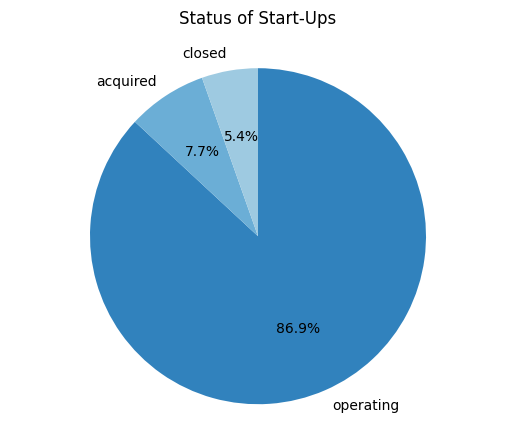

In [128]:
status = data.status.value_counts()         #comptage du nbre de fois ou apparait la colonne status( operation, acquired, closed)

plt.figure()                                #creation d'une nouvelle figure

# Palette de couleurs
cmap = plt.get_cmap("tab20c")               # choix de la palette de couleurs ici 20 couleurs différentes
colors = cmap(np.arange(len(status)))       # comptage du nombre de status pour définir le nombre de couleurs différentes

# Graphique circulaire plein
plt.pie(
    status.values,                          # valeurs numériques à afficher
    colors=colors,                          # couleurs des parts
    labels=status.index,                    # noms des statuts=libellés ("operating", etc.)
    autopct='%1.1f%%',                      # affiche le % avec 1 chiffre après la virgule
    startangle=90,                          # commence à 90° (en haut du cercle)
    counterclock=False                      # tourne dans le sens des aiguilles d’une montre
)

plt.title('Status of Start-Ups', pad=20)    # titre avec espacement vertical pad=20
plt.axis('equal')                           # pour garder le cercle bien rond
plt.show()                                  # affichage

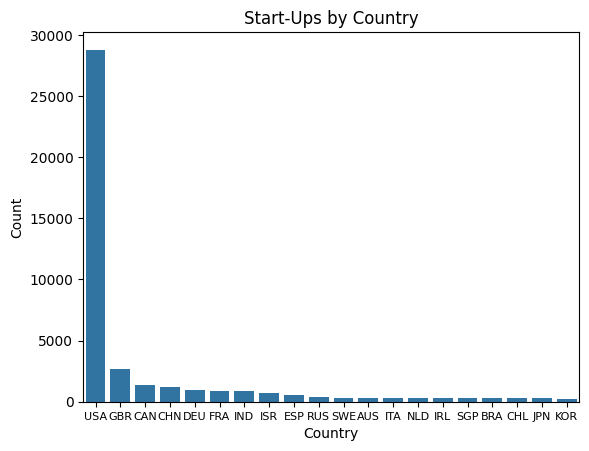

In [129]:
# Comptage par pays
counts = data['country_code'].value_counts()

# Bar chart (Top 10 pays)
sns.barplot(x=counts.index[:20], y=counts.values[:20])
plt.title('Start-Ups by Country')
plt.xlabel('Country')
plt.ylabel('Count')

# Réduction de la taille du texte sur l’axe des abscisses
plt.xticks(fontsize=8)

plt.show()

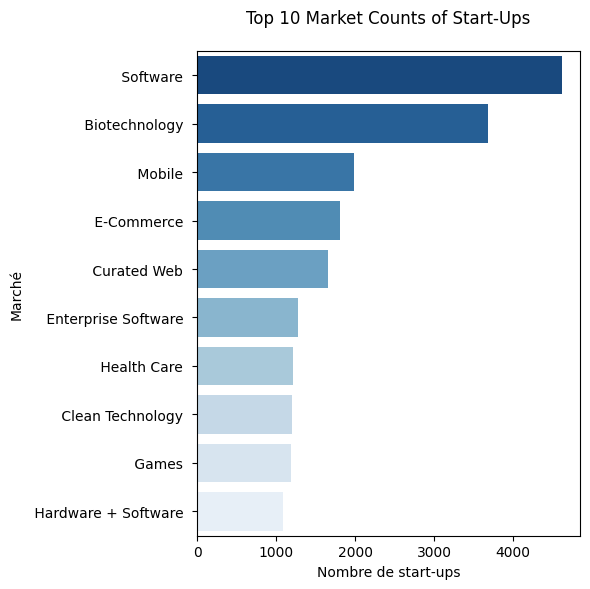

In [130]:
# Compter les marchés les plus fréquents
markets_count = data['market'].value_counts()

# Garder les 10 marchés les plus fréquents avec plus de 1000 occurrences
top_markets = markets_count[markets_count > 1000].head(10)

# Convertir en DataFrame
top_markets_df = top_markets.to_frame()

# Renommer les colonnes pour accéder plus facilement aux données
top_markets_df.columns = ['count']

plt.figure(figsize=(6, 6))
ax = sns.barplot(
    y=top_markets_df.index,
    x=top_markets_df['count'],
    hue=top_markets_df.index,
    legend=False,
    orient='h',
    palette='Blues_r'
)
ax.set_title('Top 10 Market Counts of Start-Ups', pad=20)
ax.set_xlabel('Nombre de start-ups')
ax.set_ylabel('Marché')
plt.tight_layout()
plt.show()

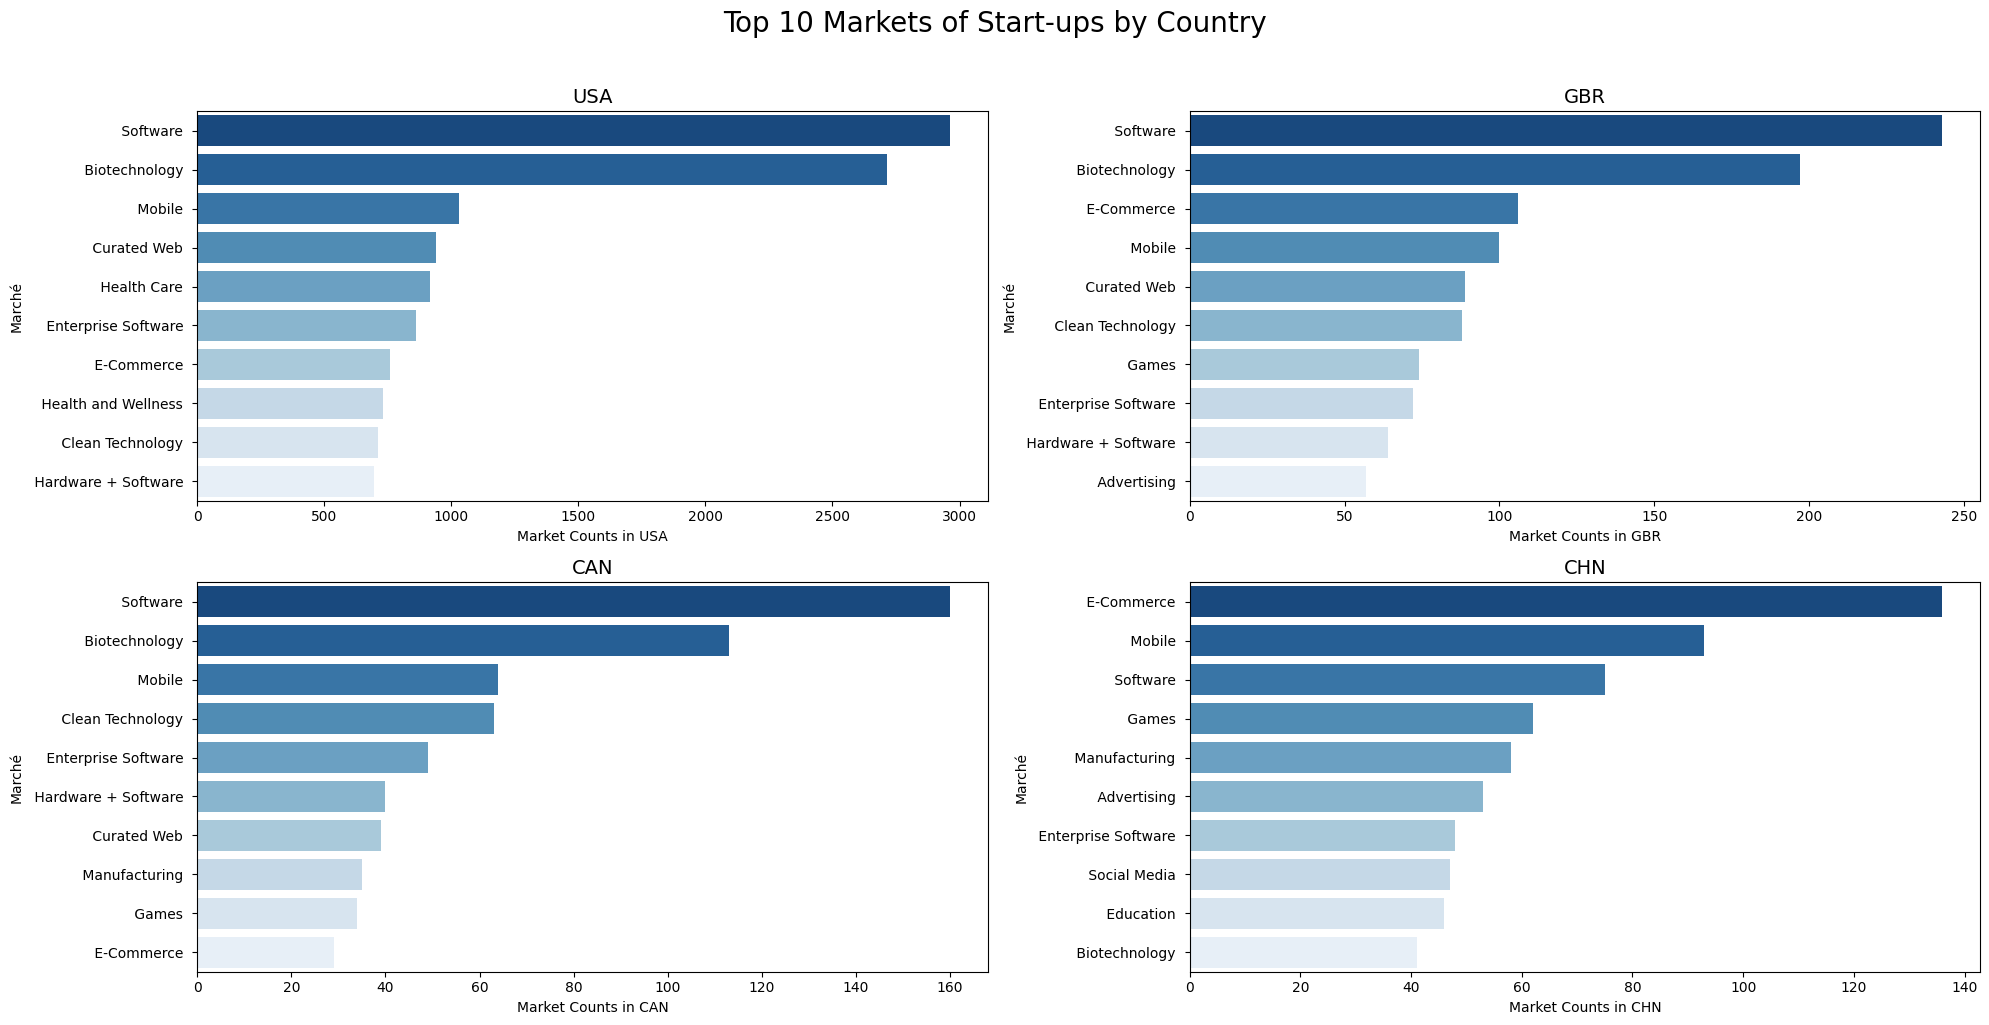

In [131]:
# 1. Supprimer les lignes sans pays ou sans marché
filtered_data = data.dropna(subset=['country_code', 'market'])

# 2. Compter le nombre de start-ups par marché et par pays
grouped = filtered_data.groupby(['country_code', 'market']).size().reset_index(name='count') 
# On regroupe les données par pays (country_code) et par marché (market), puis on compte combien de start-ups existent dans chaque couple pays/marché. 
# Le reset_index(name='count') transforme le résultat en DataFrame avec une colonne count.

# 3. Conserver uniquement les pays d'intérêt
countries = ['USA', 'GBR', 'CAN', 'CHN']
grouped = grouped[grouped['country_code'].isin(countries)]          # grouped['country_code'] : Sélectionne la colonne des pays dans le DataFrame grouped.      
                                                                    # isin(countries) : Vérifie pour chaque ligne si la valeur dans country_code fait partie de la liste countries.Résultat : une série de booléens (True ou False).
                                                                    # Tri chaque groupe de pays par nombre de start-ups
                                                                    # Sauvegarde le tout dans une structure facile à utiliser : un DataFrame multi-indexé

market_con = grouped.sort_values(['country_code', 'count'], ascending=[True, False])        #Tri chaque groupe par nombre de start-ups. On trie d’abord par pays (ordre alphabétique), puis à l’intérieur de chaque pays, on trie du marché le plus représenté au moins représenté
market_con = market_con.set_index(['country_code', 'market'])                               #Converti country_code et market en index (double index), ce qui permet d'accéder facilement aux 10 premiers marchés de chaque pays via market_con.loc['USA'].

fig, axes = plt.subplots(2, 2, figsize=(20, 10))                    # creation d'une figure avec une grille de 2 lignes et 2 colonnes + definition de la taille 
cont = ['USA', 'GBR', 'CAN', 'CHN']

for con, ax in zip(cont, axes.flatten()):           # fig est la figure globale. 
                                                    # axes est un tableau 2D contenant les axes individuels pour chaque graphique (soit un tableau de 4 objets matplotlib ax).
                                                    # axes.flatten(): Transforme le tableau 2D axes en une liste plate de 4 éléments [ax1, ax2, ax3, ax4].
                                                    # zip(cont, axes.flatten()):Associe chaque pays à un axe de la grille. ('USA', ax1),('GBR', ax2)...
                                                    # con : code pays (ex:USA)
                                                    # ax : axe sur lequel le graphique est déssiné
   
    sns.barplot(
        y=market_con.loc[con].index[:10],           # les 10 marchés les plus fréquents du pays
        x=market_con.loc[con]['count'][:10],        # leur nombre
        orient='h',                                 # graphique horizontal
        hue=market_con.loc[con].index[0:10],        # pour eviter les warning déclenché par sns.barplot du a la version >0.13 de seaborn()
        palette='Blues_r',                          # l'axe où dessiner
        ax=ax
    )
    ax.set_xlabel(f'Market Counts in {con}')
    ax.set_ylabel('Marché')
    ax.set_title(f'{con}', fontsize=14)

plt.suptitle('Top 10 Markets of Start-ups by Country', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

In [135]:
top_markets=(data.market.value_counts()[data.market.value_counts()>20]).index       # On compte combien de start-ups existent dans chaque marché (market.value_counts()).
                                                                                    # On garde uniquement les marchés qui apparaissent plus de 20 fois. 
                                                                                    # .index permet d’obtenir la liste des noms de ces marchés (pas les valeurs).
                                                                                    # Cela permet de se concentrer sur des marchés suffisamment représentés dans les données.

sub_data=data[data.market.isin(top_markets)]                                        #On garde uniquement les lignes du dataset dont le marché fait partie de top_markets.



status_market_1=sub_data.groupby('market')['status'].value_counts(normalize=True).to_frame()    # On groupe les données par marché et par statut (closed, operating, etc.).
                                                                                                # Normalize=True permet de calculer la proportion (%) au lieu du nombre brut
                                                                                                # On transforme le résultat en DataFrame et on renomme la colonne en 'prop'.
status_market_1.columns=['prop']
status_market_2=sub_data.groupby('market')['status'].value_counts().to_frame()
status_market_2.columns=['quantity']
status_market=pd.concat([status_market_1,status_market_2],axis=1)
status_market.reset_index()
status_market_closed=status_market.query('status=="closed"').reset_index(level=1)
status_market_closed.sort_values(by='prop',ascending=False)[0:10].style.background_gradient(cmap='Reds',subset=['prop']).set_caption('Markets that most start-ups closed')

,status,prop,quantity
market,,,
Public Relations,closed,0.204678,35
Coupons,closed,0.200000,7
VoIP,closed,0.172414,5
Facebook Applications,closed,0.169014,12
Location Based Services,closed,0.166667,10
Web Tools,closed,0.159091,7
iPhone,closed,0.156250,10
Curated Web,closed,0.155215,253
Social Network Media,closed,0.140351,24


In [133]:
status_market_closed.sort_values(by='prop',ascending=True)[0:10].style.background_gradient(cmap='Greens_r',subset=['prop']).set_caption('Markets that least start-ups closed')

,status,prop,quantity
market,,,
Medical,closed,0.007722,2
Technology,closed,0.007968,2
Consumer Electronics,closed,0.009259,1
Information Technology,closed,0.011236,1
Transportation,closed,0.012422,2
Services,closed,0.012658,1
Wireless,closed,0.013514,1
Telecommunications,closed,0.015152,1
Brand Marketing,closed,0.015152,1


In [134]:
status_market_acquired=status_market.query('status=="acquired"').reset_index(level=1)
status_market_acquired.sort_values(by='prop',ascending=False)[0:10].style.background_gradient(cmap='Blues',subset=['prop']).set_caption('Markets that most start-ups acquired')

,status,prop,quantity
market,,,
Chat,acquired,0.241379,7
Cloud Management,acquired,0.240000,6
Storage,acquired,0.232143,13
VoIP,acquired,0.206897,6
Web Hosting,acquired,0.193622,85
Wireless,acquired,0.189189,14
Semiconductors,acquired,0.179074,89
Video Streaming,acquired,0.174603,11
Security,acquired,0.171875,88


In [137]:
most_recent_year = df['founded_year'].dropna().min()
print("Année la plus récente :", int(most_recent_year))

Année la plus récente : 1902
